In [2]:
# path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"
# path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"

path = "/lustre/LHCb/carlos.arenas/data/v009_pmu7-fn0k-fc0-ww3_inelastic_none_1_1e4.hepmc"
local_path = "../data//v009_pmu7-fn0k-fc0-ww3_inelastic_none_1_1e4.hepmc"

In [3]:
with open(local_path, "r") as file:
    lines = file.readlines()

event_lines = []
for i, line in enumerate(lines):
    values = line.split(" ")

    if values[0] == "E":
        event_id = int(values[1])
        event_lines.append([event_id, i])

event_lines.append([0, len(lines) - 1])

print(f"Hay {len(event_lines) - 1} eventos")

Hay 90 eventos


In [4]:
import sys
sys.path.insert(0, "../cobra/src")           # so Python can find the cobra package
from cobra import load_detector_from_yaml

# detector = load_detector_from_yaml("/lustre/LHCb/carlos.arenas/cobra/config/codex-beta.yaml")
detector = load_detector_from_yaml("../cobra/config/codex-beta.yaml")

c:\Users\carlo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pyhepmc
import numpy as np
from cobra import StripDecoder
from cobra.geometry import transform_surface
from cobra.geometry import strip_to_global_position

def strip_points_module_singlet(detector, strips, row_ids):
    points = []
    module_singlets = []
    new_row_ids = []

    # print(f"lens: {len(strips)}, {len(row_ids)}")

    for module_id in {int(r[1]) for r in strips}:       # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = {row_ids[i]: strips[i] for i in range(len(strips)) if int(strips[i][0]) == module_id and int(strips[i][1]) == slot}
            phi_strips = {row_id: int(strip[2]) for row_id, strip in here.items() if int(strip[4]) == 0}
            eta_strips = {row_id: int(strip[2]) for row_id, strip in here.items() if int(strip[4]) == 1}
            singlet = detector.singlets[module.singlet_ids[slot]]
            for row_id_phi, phi in phi_strips.items():
                for row_id_eta, eta in eta_strips.items():
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)

                    time_eta = here[row_id_eta][3]
                    time_phi = here[row_id_phi][3]
                    if abs(time_eta - time_phi) < 2:
                        point = np.append(point, (time_eta + time_phi)/2)
                    else:
                        point = np.append(point, np.nan)
                    # time_phi = get_time()

                    points.append(point)
                    module_singlets.append([module_id, slot])
                    
                    new_row_ids.append([row_id_phi, row_id_eta])
                    
    return np.array(points), module_singlets, new_row_ids

def get_hit_points(event):
    rows = []
    raw_banks_id = []
    for key, value in event.attributes.items():
        if key.startswith("RawBank_"):
            raw_bank_id = int(key.split("_")[-1])
            module, strip, time0, time1 = [int(x) for x in str(value).split()]

            rows.append([raw_bank_id, module, strip, time0, time1])           # 0 = sourceID placeholder
            raw_banks_id.append(raw_bank_id)

    raw_banks = np.array(rows, dtype=np.int16)

    strips = []
    new_raw_banks_id = []

    for i, raw_bank in enumerate(raw_banks):
        current_strips = StripDecoder()._process(np.array([raw_bank]))
        for strip in current_strips:
            strips.append(strip)
            new_raw_banks_id.append(raw_banks_id[i])

    raw_banks_id = new_raw_banks_id

    # strips = StripDecoder()._process(raw_banks)

    points, module_singlets, new_raw_banks_id = strip_points_module_singlet(detector, strips, raw_banks_id)

    return points, module_singlets, new_raw_banks_id

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_detector(ax, view = "front", zoom = "zoom_in"):
    for module in detector.modules.values():
        corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
        lo, hi = corners.min(axis=0), corners.max(axis=0)
        if view == "front":
            ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1], facecolor="lightgreen", alpha=0.3))
        elif view == "side":
            ax.add_patch(plt.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2], facecolor="lightgreen", alpha=0.3))

    ax.set_xlabel("x [m]")
    ax.set_box_aspect(1)

    if view == "front":
        ax.set_ylabel("y [m]");
        if zoom == "zoom_in":
            ax.set_xlim(left= 29, right= 33)
            ax.set_ylim(bottom= -6, top= -3)
        elif zoom == "zoom_medium":
            ax.set_xlim(left= 25, right= 33)
            ax.set_ylim(bottom= -6, top= -2)
        elif zoom == "zoom_out":
            ax.set_xlim(left=-10, right=32)
            ax.set_ylim(bottom=-10, top=25)
        elif zoom == "zooom_in":
            ax.set_xlim(left= 29.7, right= 29.9)
            ax.set_ylim(bottom= -5.3, top= -5)
    if view == "side":
        ax.set_ylabel("z [m]");
        if zoom == "zoom_out":
            ax.set_xlim(left=-10, right=32)
            ax.set_ylim(bottom=-10, top=25)
        elif zoom == "zoom_in":
            ax.set_xlim(left=29, right=33)
            ax.set_ylim(bottom=7, top=11)

In [7]:
def cov(X, Y):
    return sum((X - np.mean(X))*(Y - np.mean(Y))) / (len(X) - 1)

def lineal_regression(X, Y):
    if len(X) <= 2: return None

    # lmq -> y = mx + n
    m = cov(X,Y)/cov(X,X)
    n = np.mean(Y) - m*np.mean(X)

    err = Y - m*X - n
    R = 1 - np.dot(err, err)/cov(Y, Y)

    chi2 = np.dot(err, err) / (len(X) - 2)

    return m, n, R, chi2

In [8]:
def match_hits_particles(raw_banks_id):
    # Match points with particles
    # points[i] <-> points_particle[i]

    global raw_banks_particles

    global points_particle
    points_particle.clear()

    points_particle = []
    for phi_id, eta_id in raw_banks_id:
        particle_id = raw_banks_particles[phi_id]
        if particle_id == raw_banks_particles[eta_id]:
            points_particle.append(particle_id)
        else:
            points_particle.append(None)

def sort_points_by_module():
    global event
    
    global hit_points
    global sorted_points_id

    hit_points, module_singlets, raw_banks_id = get_hit_points(event)
    print(f"Hay: {len(hit_points)} puntos")

    # sort points by module, singlet:
    sorted_points_id.clear()
    modules = {module_singlet[0] for module_singlet in module_singlets}
    for module in modules:
        sorted_points_id.append([[],[],[]])
        for i, P in enumerate(hit_points):
            if module_singlets[i][0] == module:
                sorted_points_id[-1][module_singlets[i][1]].append(i)

    match_hits_particles(raw_banks_id)

In [9]:
def group_inside_modules(sorted_points_id):
    global hit_points

    clusters = []
    min_distance = 0.003
    for module_points in sorted_points_id:
        module_selected_points = [0]*sum([len(x) for x in module_points])

        for i, id1 in enumerate(module_points[0]):
            if not module_selected_points[i]:
                P1 = hit_points[id1]

                d2_min = min_distance
                for j, id2 in enumerate(module_points[1]):
                    if not module_selected_points[j + len(module_points[0])]:
                        P2 = hit_points[id2]

                        d2_ij = np.dot((P2 - P1), (P2 - P1))
                        if d2_ij < d2_min:
                            d2_min = d2_ij

                    if d2_min < min_distance:
                        d2_min = min_distance
                        for k, id3 in enumerate(module_points[2]):
                            if not module_selected_points[k + len(module_points[0]) + len(module_points[1])]:
                                P3 = hit_points[id3]

                                d2_ij = np.dot((P3 - P2), (P3 - P2))
                                if d2_ij < d2_min:
                                    d2_min = d2_ij

                                if d2_min < min_distance:
                                    # print("Hola", i, j + len(module_points[0]), k + len(module_points[0]) + len(module_points[1]))

                                    X = np.array([P1, P2, P3])
                                    my, ny, Ry, chi2x = lineal_regression(X[:,0], X[:,1])
                                    mz, nz, Rz, chi2y = lineal_regression(X[:,0], X[:,2])

                                    if Ry > 0.7 and Rz > 0.7:
                                        clusters.append([id1, id2, id3])
                                        # module_selected_points[i] = 1
                                        # module_selected_points[j + len(module_points[0])] = 1
                                        # module_selected_points[k + len(module_points[0]) + len(module_points[1])] = 1

                                    break
    return clusters

In [10]:
def fill_dicc():
    global event_nr
    global particle_links
    global raw_banks_particles

    particle_links.clear()
    raw_banks_particles.clear()

    for line in lines[event_lines[event_nr][1]:event_lines[event_nr + 1][1]]:
        values = line.split()

        if values[0] == "A":
            if values[2] == "RawBankLinks":
                particle_id = int(values[1])
                particle_links[particle_id] = [int(x) for x in values[3:]]

                for x in values[3:]:
                    raw_banks_particles[abs(int(x))] = particle_id

            elif values[2].startswith("RawBank_"):
                raw_bank_id = int(values[2].split("_")[-1])
                raw_bank = [int(x) for x in values[3:]]

                raw_banks[raw_bank_id] = raw_bank

def plot_event_views():
    global hit_points

    fig, axs = plt.subplots(2)
    plot_detector(axs[0], zoom = "zooom_in")
    axs[0].scatter(hit_points[:,0], hit_points[:,1])

    plot_detector(axs[1], view = "side", zoom = "zoom_in")
    axs[1].scatter(hit_points[:,0], hit_points[:,2])
    plt.show()

In [11]:
def calc_ef(clusters):
    global points_particle

    global ef_counter
    global total_counter

    for cluster in clusters:
        same_particle = True
        for point_id in cluster[1:]:
            if points_particle[point_id] != points_particle[cluster[0]]:
                same_particle = False

        if same_particle:
            ef_counter += 1
        total_counter += 1

In [12]:
def clustering_by_proximity(hit_points):
    clusters = []
    n_points = len(hit_points)

    visited = [0]*n_points

    def visit(idx):
        if not visited[idx]:
            for i in range(n_points - idx - 1):
                j = i + idx + 1

                PQ = hit_points[j] - hit_points[idx]

                if np.dot(PQ, PQ) < 0.003:
                    clusters[-1].append(j)
                    visited[j] = 1
                    visit(j)


    for i in range(n_points):
        if not visited[i]:
            clusters.append([i])
            visit(i)

    return clusters

In [13]:
# Intenta agrupar los clústeres en parejas.
def group_pairs_clusters(clusters, hit_points):
    if len(clusters) <= 1: return [], []
    print(f"Hay: {len(clusters)} clústeres")

    cluster_groups = []
    groups_chi2 = []

    # chi2_min = 0.1
    # all_chis = []
    for i, c1 in enumerate(clusters):
        for j, c2 in enumerate(clusters[i+1:]):

            X = []
            for P_idx in c1 + c2:
                X.append(hit_points[P_idx])

            X = np.array(X)
            if len(X) > 2:
                my, ny, Ry, chi2y = lineal_regression(X[:,0], X[:,1])
                mz, nz, Rz, chi2z = lineal_regression(X[:,0], X[:,2])

                chi2 = chi2y + chi2z
                # all_chis.append(chi2)

                if chi2 < 25:
                    # Revisar que esto esté bien !!!
                    cluster_groups.append([i, j + i + 1])
                    groups_chi2.append(chi2)

    return cluster_groups, groups_chi2

def make_true_groups():
    global clusters_particle

    particles_track = {particle: [] for particle in clusters_particle}
    for i, particle in enumerate(points_particle):
        particles_track[particle].append(i)

    return particles_track


# plt.hist(all_chis, bins = 50, range = (0,0.05))
# plt.show()

In [20]:
def is_cluster_good(cluster):
    global points_particle

    goodness = True
    particle = points_particle[cluster[0]]
    for P_idx in cluster[1:]:
        if points_particle[P_idx] != particle:
            goodness = False

    if goodness:
        return goodness, particle
    else:
        return goodness, None


def make_good_cluster_pairs():
    pass

def calc_group_chi2(cluster_group, clusters):
    group = []
    for cluster_idx in cluster_group:
        group += clusters[cluster_idx]

    X = [hit_points[P_idx] for P_idx in group]
    X = np.array(X)

    if len(X) > 2:
        my, ny, Ry, chi2y = lineal_regression(X[:,0], X[:,1])
        mz, nz, Rz, chi2z = lineal_regression(X[:,0], X[:,2])

        chi2 = chi2y + chi2z

        return chi2
    else:
        return float("nan")

def calc_cluster_chi2(cluster):
    X = [hit_points[P_idx] for P_idx in cluster]
    X = np.array(X)

    if len(X) > 2:
        my, ny, Ry, chi2y = lineal_regression(X[:,0], X[:,1])
        mz, nz, Rz, chi2z = lineal_regression(X[:,0], X[:,2])

        chi2 = chi2y + chi2z

        return chi2
    else:
        return None

def calc_group_time_chi2(cluster_group, clusters):
    group = []
    for cluster_idx in cluster_group:
        group += clusters[cluster_idx]

    T = [hit_points[P_idx][3] for P_idx in group]
    T = np.array(T)

    chi2 = cov(T, T)
    if chi2 is None:
        print("Chi2 es None: ", T)

    return chi2

def calc_cluster_time_chi2(cluster):
    T = [hit_points[P_idx][3] for P_idx in cluster]
    T = np.array(T)

    chi2 = cov(T, T)
    if chi2 is None:
        print("Chi2 es None: ", T)

    return chi2

def calc_group_speed_chi2(cluster_group, clusters):
    group = []
    for cluster_idx in cluster_group:
        group += clusters[cluster_idx]

    X = [hit_points[P_idx] for P_idx in group]
    X = np.array(X)

    if len(X) > 2:
        vx, x0, R, chi2 = lineal_regression(X[:,3], X[:,0])

        return vx, chi2
    else:
        return float("nan"), float("nan")

In [15]:
def group_clusters(clusters):
    cluster_groups = []
    groups_chi2 = []
    for i, c1 in enumerate(clusters):
        for j_, c2 in enumerate(clusters[i+1:]):
            j = j_ + i + 1
            for k_, c3 in enumerate(clusters[j+1:]):
                k = k_ + j + 1

                global hit_points
                X = np.array([hit_points[idx] for idx in c1 + c2 + c3])

                my, ny, Ry, chi2y = lineal_regression(X[:,0], X[:,1])
                mz, nz, Rz, chi2z = lineal_regression(X[:,0], X[:,2])

                chi2 = 2 - Ry - Rz
                chi2 = chi2y + chi2z

                if chi2 < 10:
                    cluster_groups.append([i, j, k])
                    groups_chi2.append(chi2)

    return cluster_groups, groups_chi2

# Unused by  the momment
def extend_cluster_groups(clusters, cluster_groups, groups_chi2):
    for i, cluster_group in enumerate(cluster_groups):
        for j, cluster in enumerate(clusters):
            if j not in cluster_group:

                global hit_points
                X = np.array([hit_points[idx] for idx in sum([clusters[cluster_id] for cluster_id in cluster_group], []) + cluster])

                my, ny, Ry = lineal_regression(X[:,0], X[:,1])
                mz, nz, Rz = lineal_regression(X[:,0], X[:,2])

                # chi2 = 2 - Ry - Rz

                if chi2 < 0.01:
                    cluster_groups[i].append(j)
                    groups_chi2[i] = chi2

    return cluster_groups, groups_chi2

def reject_cluster_groups(clusters, cluster_groups, groups_chi2):
    new_cluster_groups = []
    new_chi2s = []

    for c_id, c in enumerate(clusters):
        min_chi2 = 2
        current_cluster_group = -1
        for i, cluster_group in enumerate(cluster_groups):
            if c_id in cluster_group:
                if groups_chi2[i] < min_chi2:
                    min_chi2 = groups_chi2[i]
                    current_cluster_group = i

        if min_chi2 < 2:
            if not current_cluster_group in new_cluster_groups:
                new_cluster_groups.append(current_cluster_group)
                new_chi2s.append(min_chi2)

    return [cluster_groups[x] for x in new_cluster_groups], new_chi2s

In [16]:
def plot_cluster_groups(cluster_groups, clusters):
    fig, ax = plt.subplots()

    global hit_points
    X = np.array(hit_points)
    ax.scatter(X[:,0], X[:,1])

    for cluster_group in cluster_groups:
        Y = []
        for cluster_id in cluster_group:
            for P_idx in clusters[cluster_id]:
                Y.append(hit_points[P_idx])

        Y = np.array(Y)
        my, ny, Ry = lineal_regression(Y[:,0], Y[:,1])

        a = min(Y[:,0])
        b = max(Y[:,0])

        e = 0.1*(b-a)
        a -= e
        b += e

        ax.plot([a,b], my*np.array([a,b]) + ny)

    plt.show()
            

Hay: 4 puntos
Total clusteres: 1
Buenos clusteres: 1
1 1
Hay: 241 puntos


C:\Users\carlo\AppData\Local\Temp\ipykernel_12700\905687456.py:8: RuntimeWarning: invalid value encountered in scalar divide
  m = cov(X,Y)/cov(X,X)
C:\Users\carlo\AppData\Local\Temp\ipykernel_12700\905687456.py:12: RuntimeWarning: invalid value encountered in scalar divide
  R = 1 - np.dot(err, err)/cov(Y, Y)


Total clusteres: 126
Buenos clusteres: 9
0.01052273497289537
nan
nan
nan
nan
nan
nan
nan
0.012794737523915776
0.035395183952487204
0.001375762562692863
0.010738575215242395
0.001128438313802129
0.013010577766262802
0.03561102419483423
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
nan
116 127
Hay: 0 puntos
Total clusteres: 0
Buenos clusteres: 0
116 127
Hay: 29 puntos
Total clusteres: 7
Buenos clusteres: 7
0.0005505452930266711
0.0004010394079918411
0.0007765219713082388
0.0004198457922851839
0.00044193535174711653
0.0004201015079743656
0.0007196078093184855
0.0009264185257109086
0.0006665810325124979
0.0006649086898618524
0.0007396806217005433
0.0002998925121700254
0.00030085758473148727
0.00046279387229190453
0.0004536042712388333
0.0002986742368103896
0.00047760493974609395
0.00048828125
0.0005356883089084297
0.0006186314575883735
0.0004816938920454573
123 134
Hay: 6 puntos
Total clusteres: 1
Buenos clusteres: 1
124 135
Hay: 4 puntos
Total clusteres: 

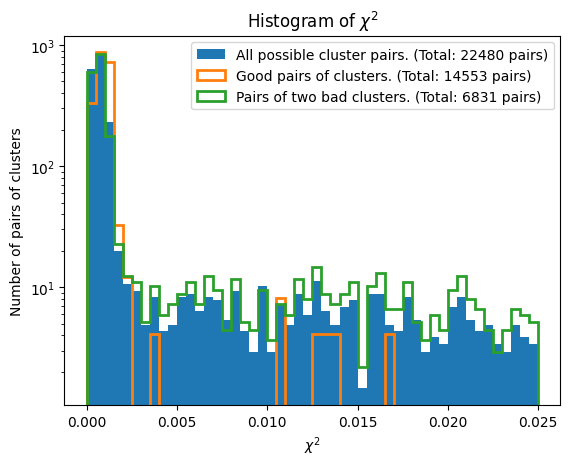

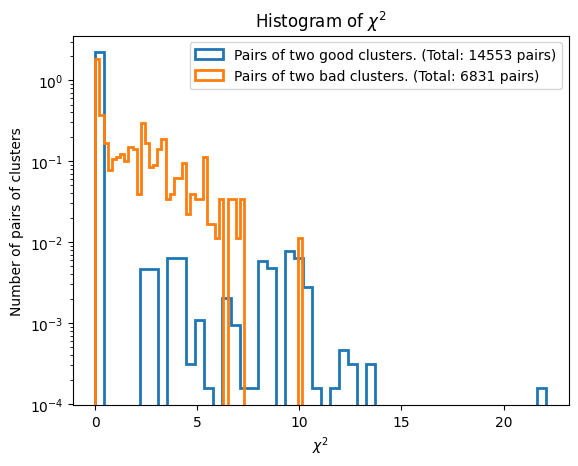

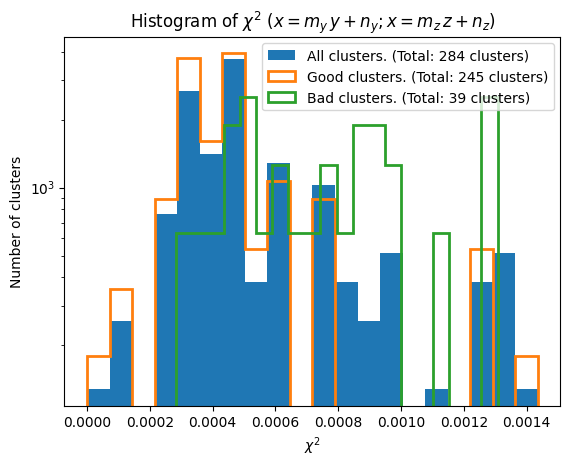

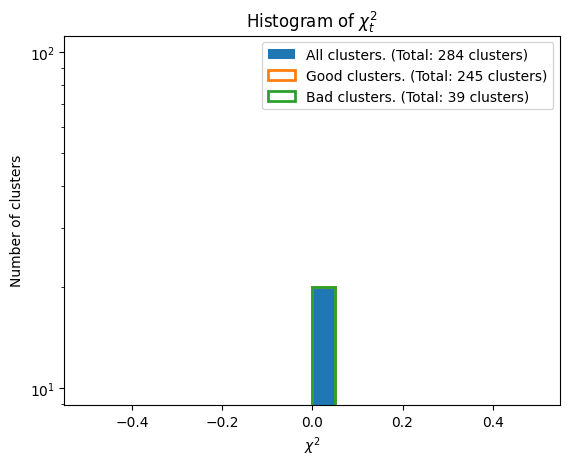

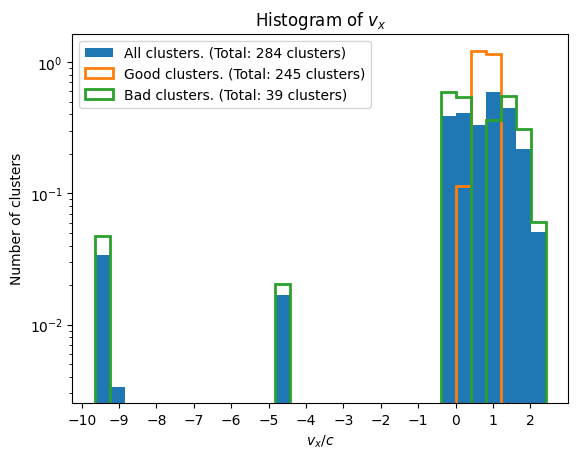

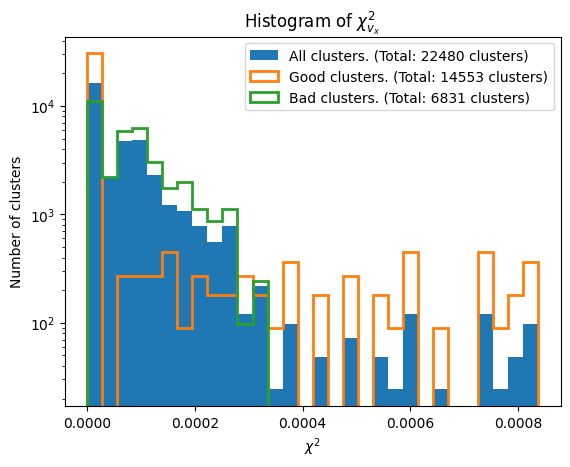

In [21]:
event_nr = -1

raw_banks = {}

particle_links = {}
raw_banks_particles = {}

hit_points = []
sorted_points_id = []

points_particle = {}
clusters_particle = []

ef_counter = 0
total_counter = 0

# ==========
# Keys, Features y Labels que darle al BDT:

tracks_event = []


mean_cluster_sizes = []
cluster_size_SDs = []

cluster_sizes = []

tracks_goodness = []

# ==========

all_pairs_chi2 = []
all_good_pairs_chi2 = []
all_bad_pairs_chi2 = []

all_good_pairs_time_chi2 = []
all_bad_pairs_time_chi2 = []

# ==========

# Calculo de chi2 espacial de clusteres
all_clusters_chi2 = []
all_good_clusters_chi2 = []
all_bad_clusters_chi2 = []

# Calculo de chi2 temporal de clusters
all_clusters_time_chi2 = []
all_good_clusters_time_chi2 = []
all_bad_clusters_time_chi2 = []

# ==========

all_pairs_speed_chi2 = []
all_good_pairs_speed_chi2 = []
all_bad_pairs_speed_chi2 = []

all_speeds = []
all_good_speeds = []
all_bad_speeds = []

# ==========

with pyhepmc.open(local_path) as f:
    event_it = iter(f)

    for event_idx in range(99):
        try:
            event = next(event_it)
            event_nr += 1
        except StopIteration:
            break

        fill_dicc()
        sort_points_by_module()

        clusters = group_inside_modules(sorted_points_id)
        clusters = clustering_by_proximity(hit_points)
        # print("Clústeres:")
        # print(clusters)

        calc_ef(clusters)

        # cluster_groups, all_chis_event = group_pairs_clusters(clusters, hit_points)
        cluster_pairs = []
        for i in range(len(clusters)):
            for j in range(len(clusters)):
                if i < j:
                    cluster_pairs.append([i, j])

        for pair in cluster_pairs:
            chi2 = calc_group_chi2(pair, clusters)
            if chi2 is not None: all_pairs_chi2.append(chi2)



        # global clusters_particle
        clusters_particle.clear()
        for i, c in enumerate(clusters):
            goodness, particle = is_cluster_good(c)
            if goodness:
                clusters_particle.append(particle)
            else:
                clusters_particle.append(None)

        good_clusters = [clusters[i] for i, x in enumerate(clusters_particle) if x is not None]
        bad_clusters = [clusters[i] for i, x in enumerate(clusters_particle) if x is None]
        print(f"Total clusteres: {len(clusters)}")
        print(f"Buenos clusteres: {len(good_clusters)}")
                        
        good_cluster_pairs = []
        n_good_clusters = len(good_clusters)
        for i in range(n_good_clusters):
            for j in range(n_good_clusters):
                if i < j:
                    good_cluster_pairs.append([i, j])

        bad_cluster_pairs = []
        n_bad_clusters = len(bad_clusters)
        for i in range(n_bad_clusters):
            for j in range(n_bad_clusters):
                if i < j:
                    bad_cluster_pairs.append([i,j])


        # ================
        # Relleno las propiedades para el BDT

        tracks_event += [event_idx]*len(cluster_pairs)
        for pair in cluster_pairs:
            sizes = np.array((len(clusters[pair[0]]), len(clusters[pair[1]])))
            mean_cluster_sizes.append(np.mean(sizes))
            cluster_size_SDs.append(np.sqrt(cov(sizes, sizes)))

            # print(f"Longitudes clusters_particle: {len(clusters)}, {len(clusters_particle)}, {pair[0]}, {pair[1]}")

            r1 = clusters_particle[pair[0]]
            r2 = clusters_particle[pair[1]]

            if r1 == r2 and r1 is not None:
                tracks_goodness.append(1)
            else:
                tracks_goodness.append(0)


        for c in clusters:
            cluster_sizes.append(len(c))

        # ================


        for cluster_pair in good_cluster_pairs:
            chi2 = calc_group_chi2(cluster_pair, clusters)
            print(chi2)
            all_good_pairs_chi2.append(chi2)
                        
        for cluster_pair in bad_cluster_pairs:
            chi2 = calc_group_chi2(cluster_pair, clusters)
            all_bad_pairs_chi2.append(chi2)

        # ==============

        for cluster_pair in good_cluster_pairs:
            all_good_pairs_time_chi2.append(calc_group_time_chi2(cluster_pair, clusters))

        for cluster_pair in bad_cluster_pairs:
            all_bad_pairs_time_chi2.append(calc_group_time_chi2(cluster_pair, clusters))

        # ======
        # ==============
        # Ajuste espacial por cluster

        for cluster in good_clusters:
            if len(cluster) > 2:
                all_good_clusters_chi2.append(calc_cluster_chi2(cluster))
        for cluster in bad_clusters:
            if len(cluster) > 2:
                all_bad_clusters_chi2.append(calc_cluster_chi2(cluster))
        all_clusters_chi2 = all_good_clusters_chi2 + all_bad_clusters_chi2

        # ==============
        # Ajuste temporal por cluster

        for cluster in good_clusters:
            if len(cluster) > 2:
                all_good_clusters_time_chi2.append(calc_cluster_time_chi2(cluster))
        for cluster in bad_clusters:
            if len(cluster) > 2:
                all_bad_clusters_time_chi2.append(calc_cluster_time_chi2(cluster))
        all_clusters_time_chi2 = all_good_clusters_time_chi2 + all_bad_clusters_time_chi2

        # ===========
        # Ajuste de velocidad v_x
        for pair in cluster_pairs:
            vx, chi2 = calc_group_speed_chi2(pair, clusters)
            all_pairs_speed_chi2.append(chi2)
            vx = (vx/(0.833*1e-9))/(3*1e8)
            all_speeds.append(vx)

        for cluster_pair in good_cluster_pairs:
            vx, chi2 = calc_group_speed_chi2(cluster_pair, clusters)
            if chi2 is not None: all_good_pairs_speed_chi2.append(chi2)
            if vx is not None: 
                vx = (vx/(0.833*1e-9))/(3*1e8)
                all_good_speeds.append(vx)

        for cluster_pair in bad_cluster_pairs:
            vx, chi2 = calc_group_speed_chi2(cluster_pair, clusters)
            if chi2 is not None: all_bad_pairs_speed_chi2.append(chi2)
            if vx is not None: 
                vx = (vx/(0.833*1e-9))/(3*1e8)
                all_bad_speeds.append(vx)


        # good_clusters_pairs, good_pairs_chi2 = make_good_cluster_pairs(clusters_particle)

        # Aun no
        # cluster_groups, groups_chi2 = group_clusters(clusters)
        
        """
        cluster_groups, groups_chi2 = extend_cluster_groups(clusters, cluster_groups, groups_chi2)

        
        print("Cluster groups:")
        print(cluster_groups)

        
        cluster_groups, groups_chi2 = reject_cluster_groups(clusters, cluster_groups, groups_chi2)
        
        print("Cluster groups:")
        print(cluster_groups)
        """


        # print(f"Lengths: {len(clusters)}, {len(cluster_groups)}")
        # print(f"Chis: {groups_chi2}")

        # plot_cluster_groups(cluster_groups, clusters)
        

        # cluster_groups = extend_cluster_groups(cluster_groups, clusters)

        print(ef_counter, total_counter)

# all_pairs_chi2 = [chi2 for chi2 in all_pairs_chi2 if chi2 is not None]

all_good_pairs_chi2 = [chi2 for chi2 in all_good_pairs_chi2 if chi2 is not None]
all_bad_pairs_chi2 = [chi2 for chi2 in all_bad_pairs_chi2 if chi2 is not None]
all_good_pairs_time_chi2 = [chi2 for chi2 in all_good_pairs_time_chi2 if chi2 is not None]
all_bad_pairs_time_chi2 = [chi2 for chi2 in all_bad_pairs_time_chi2 if chi2 is not None]

fig, ax = plt.subplots()

ax.hist(all_pairs_chi2, bins = 50, range = (0, 0.025), log=True,  density = True, label = f"All possible cluster pairs. (Total: {len(all_pairs_chi2)} pairs)")
ax.hist(all_good_pairs_chi2, bins = 50, range = (0, 0.025), log=True, density = True, histtype="step", linewidth= 2, label = f"Good pairs of clusters. (Total: {len(all_good_pairs_chi2)} pairs)")
ax.hist(all_bad_pairs_chi2, bins = 50, range = (0, 0.025), log=True, density = True, histtype="step", linewidth= 2, label = f"Pairs of two bad clusters. (Total: {len(all_bad_pairs_chi2)} pairs)")
ax.set_yscale('log')
ax.set_title(r"Histogram of $\chi^2$")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel(r"Number of pairs of clusters")

ax.legend()
plt.show()

fig, ax = plt.subplots()

# ax.hist(all_events_chi2,
#          bins = 50, log=True,  density = True, label = f"All possible cluster pairs. (Total: {len(all_events_chi2)} pairs)")
ax.hist(all_good_pairs_time_chi2,
         bins = 50, log=True, density = True, histtype="step", linewidth= 2, label = f"Pairs of two good clusters. (Total: {len(all_good_pairs_time_chi2)} pairs)")
ax.hist(all_bad_pairs_time_chi2,
         bins = 50, log=True, density = True, histtype="step", linewidth= 2, label = f"Pairs of two bad clusters. (Total: {len(all_bad_pairs_time_chi2)} pairs)")

ax.set_yscale('log')
ax.set_title(r"Histogram of $\chi^2$")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel(r"Number of pairs of clusters")

plt.legend()
plt.show()

# ===============
fig, ax = plt.subplots()

ax.hist(all_clusters_chi2, bins = 20, log=True,  density = True, label = f"All clusters. (Total: {len(all_clusters_chi2)} clusters)")
ax.hist(all_good_clusters_chi2, bins = 20, log=True, density = True, histtype="step", linewidth= 2, label = f"Good clusters. (Total: {len(all_good_clusters_chi2)} clusters)")
ax.hist(all_bad_clusters_chi2, bins = 20, log=True, density = True, histtype="step", linewidth= 2, label = f"Bad clusters. (Total: {len(all_bad_clusters_chi2)} clusters)")
ax.set_yscale('log')
ax.set_title(r"Histogram of $\chi^2$ $(x = m_y\,y + n_y ; x = m_z\,z + n_z)$")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel(r"Number of clusters")

ax.legend()
plt.show()

# ===============
fig, ax = plt.subplots()

ax.hist(all_clusters_time_chi2, bins = 20, log=True,  density = True, label = f"All clusters. (Total: {len(all_clusters_time_chi2)} clusters)")
ax.hist(all_good_clusters_time_chi2, bins = 20, log=True, density = True, histtype="step", linewidth= 2, label = f"Good clusters. (Total: {len(all_good_clusters_time_chi2)} clusters)")
ax.hist(all_bad_clusters_time_chi2, bins = 20, log=True, density = True, histtype="step", linewidth= 2, label = f"Bad clusters. (Total: {len(all_bad_clusters_time_chi2)} clusters)")
ax.set_yscale('log')
ax.set_title(r"Histogram of $\chi^2_t$")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel(r"Number of clusters")

ax.legend()
plt.show()

# ===============

fig, ax = plt.subplots()

# all_speeds = all_good_speeds + all_bad_speeds
counts, bins, _ = ax.hist(all_speeds, bins = 30, log=True,  density = True, label = f"All clusters. (Total: {len(all_clusters_time_chi2)} clusters)")
ax.hist(all_good_speeds, bins = bins, log=True, density = True, histtype="step", linewidth= 2, label = f"Good clusters. (Total: {len(all_good_clusters_time_chi2)} clusters)")
ax.hist(all_bad_speeds, bins = bins, log=True, density = True, histtype="step", linewidth= 2, label = f"Bad clusters. (Total: {len(all_bad_clusters_time_chi2)} clusters)")
ax.set_yscale('log')
ax.set_title(r"Histogram of $v_x$")
ax.set_xlabel(r"$v_x / c$")
ax.set_ylabel(r"Number of clusters")

ax.set_xticks(np.arange(-10, 3))

ax.legend()
plt.show()

# ===============

fig, ax = plt.subplots()

# all_pairs_speed_chi2 = all_good_pairs_speed_chi2 + all_bad_pairs_speed_chi2
counts, bins, _ = ax.hist(all_pairs_speed_chi2, bins = 30, log=True,  density = True, label = f"All clusters. (Total: {len(all_pairs_speed_chi2)} clusters)")
ax.hist(all_good_pairs_speed_chi2, bins = bins, log=True, density = True, histtype="step", linewidth= 2, label = f"Good clusters. (Total: {len(all_good_pairs_speed_chi2)} clusters)")
ax.hist(all_bad_pairs_speed_chi2, bins = bins, log=True, density = True, histtype="step", linewidth= 2, label = f"Bad clusters. (Total: {len(all_bad_pairs_speed_chi2)} clusters)")
ax.set_yscale('log')
ax.set_title(r"Histogram of $\chi^2_{v_x}$")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel(r"Number of clusters")

# ax.set_xticks(np.arange(-10, 3))

ax.legend()
plt.show()

# print(f"Buenos clusteres: {len([x for x in clusters_particle if x is not None])}")
# print(f"{len(good_clusters_pair_combinations)}")



In [18]:
tracks_event = np.array(tracks_event)

print(tracks_event.shape, len(tracks_event))

(22480,) 22480


In [63]:
print(len(cluster_sizes))
print(len(cluster_sizes)*(len(cluster_sizes) -1))
print(len(tracks_event))
print(len(mean_cluster_sizes))
print(len(cluster_size_SDs))

print(len(all_speeds))
print(len(all_pairs_chi2))

n_rows = len(tracks_event)
tracks_id = np.arange(n_rows)
mock = np.random.normal(loc=4.2, scale=1, size = len(tracks_event))

import pandas as pd
# , "mean_cluster_size": mean_cluster_sizes, "cluster_size_SD": cluster_size_SDs
# df = pd.DataFrame({"event_id": np.array(tracks_event), "track_id": tracks_id, "mock": mock, "good": np.array(tracks_goodness)})
# "mean_cluster_size": mean_cluster_sizes, "cluster_size_SD": cluster_size_SDs,

"""
df = pd.DataFrame({"event_id": np.array(tracks_event), "track_id": tracks_id,
                   "mean_cluster_size": mean_cluster_sizes, "cluster_size_SD": cluster_size_SDs,
                    "speed": all_speeds,
                    "good": np.array(tracks_goodness)})
"""

df = pd.DataFrame({"event_id": np.array(tracks_event), "track_id": tracks_id,
                   "mean_cluster_size": mean_cluster_sizes,
                   "spatial_chi2": all_pairs_chi2,
                    "good": np.array(tracks_goodness)})
                    
KEYS = ["event_id", "track_id"]
LABEL = "good"
FEATURES = [c for c in df.columns if c not in KEYS + [LABEL]]

"""
events = np.sort(df.event_id.unique())
print(f"validation: {df.good.unique()}")
print(tracks_goodness)
rng = np.random.default_rng(0); rng.shuffle(events)

# Dividimos los eventos en tres cestas.
n = len(events)
tr, va, te = events[:int(.4*n)], events[int(.4*n):int(.7*n)], events[int(.7*n):]
m = lambda e: df["event_id"].isin(e).to_numpy()

Xtr, ytr = df.loc[m(tr), FEATURES], df.loc[m(tr), LABEL]
Xva, yva = df.loc[m(va), FEATURES], df.loc[m(va), LABEL]
Xte, yte = df.loc[m(te), FEATURES], df.loc[m(te), LABEL]
"""

# =========
tracks = np.sort(df.track_id.unique())
rng = np.random.default_rng(0); rng.shuffle(tracks)

n = len(tracks_id)
tr, va, te = tracks[:int(.6*n)], tracks[int(.6*n):int(.8*n)], tracks[int(.8*n):]
m = lambda e: df["track_id"].isin(e).to_numpy()

Xtr, ytr = df.loc[m(tr), FEATURES], df.loc[m(tr), LABEL]
Xva, yva = df.loc[m(va), FEATURES], df.loc[m(va), LABEL]
Xte, yte = df.loc[m(te), FEATURES], df.loc[m(te), LABEL]



# ==========


print(f"y traning: {sum(ytr)}, {len(ytr) - sum(ytr)}")
print(ytr)

"""
print(Xtr)
print(Xva)
print(Xte)
"""

from sklearn.ensemble import HistGradientBoostingClassifier

clf = HistGradientBoostingClassifier(
    max_iter = 200, learning_rate=0.05, max_leaf_nodes=31,
    min_samples_leaf=50, l2_regularization=1.0,
    early_stopping=True, n_iter_no_change=30, random_state=0
)
clf.fit(Xtr, ytr)

s_tr, s_va, s_te = (clf.predict_proba(X)[:, 1] for X in (Xtr, Xva, Xte))

# Checking
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import GroupKFold, cross_val_score

print(len(s_tr))

print("AUC train %.4f val %.4f test %.4f" % (
    roc_auc_score(ytr, s_tr), roc_auc_score(yva, s_va), roc_auc_score(yte, s_te)))
print("AP %.4f" % average_precision_score(yte, s_te))

sc = cross_val_score(clf, df[FEATURES], df[LABEL], groups=df["track_id"],
                     cv=GroupKFold(4), scoring="roc_auc")
print("CV AUC %.4f ± %.4f" % (sc.mean(), sc.std()))

score = 0
s = list(s_tr) + list(s_va) + list(s_te)
for i in range(n_rows):
    score += (tracks_goodness[i])*s[i]

print(f"Final score: {score / sum(s)}")

419
175142
22480
22480
22480
22480
22480
y traning: 8464, 5024
1        0
5        0
8        0
9        0
11       0
        ..
22474    1
22475    1
22477    1
22478    1
22479    1
Name: good, Length: 13488, dtype: int64
13488
AUC train 0.9994 val 0.9987 test 0.9986
AP 0.9992
CV AUC 0.9988 ± 0.0003
Final score: 0.7561969047595792


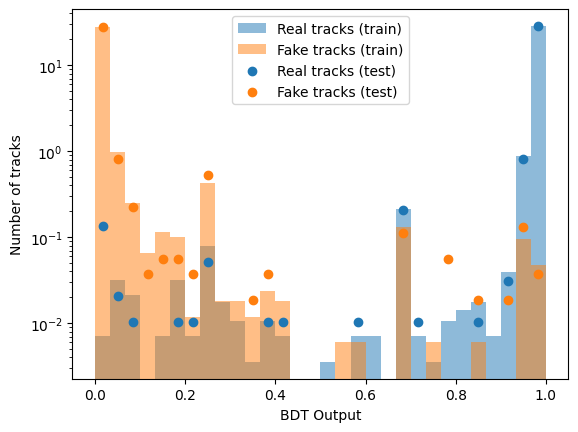

In [64]:
good_mask = yte == 1
bad_mask = yte != 1
good_s_te = s_te[good_mask]
bad_s_te = s_te[bad_mask]
good_s_tr = s_tr[ytr == 1]
bad_s_tr = s_tr[ytr == 0]

fig, ax = plt.subplots()

ax.hist(good_s_tr, bins = 30, range=(0,1), density = True, alpha = 0.5, label="Real tracks (train)")
ax.hist(bad_s_tr, bins = 30, range=(0,1), density = True, alpha = 0.5, label="Fake tracks (train)")

counts_good_s_te, bins_good_s_te, _ = ax.hist(good_s_te, bins = 30, range=(0,1), density = True, alpha = 0)
counts_bad_s_te, bins_bad_s_te, _ = ax.hist(bad_s_te, bins = 30, range=(0,1), density = True, alpha = 0)

centers_good_s_te = (bins_good_s_te[:-1] + bins_good_s_te[1:]) / 2
ax.scatter(centers_good_s_te, counts_good_s_te, label="Real tracks (test)")

centers_bad_s_te = (bins_bad_s_te[:-1] + bins_bad_s_te[1:]) / 2
ax.scatter(centers_bad_s_te, counts_bad_s_te, label = "Fake tracks (test)")


ax.set_yscale('log')
ax.set_xlabel(r"BDT Output")
ax.set_ylabel(r"Number of tracks")

plt.legend()
plt.show()

# A partir de aquí no hay más que testeo

In [29]:
with pyhepmc.open(path) as f:
    event_it = iter(f)
    event = next(event_it)
    event = next(event_it)

dummy_points, module_singlets, raw_banks_id = get_hit_points(event)

print(dummy_points)
print(raw_banks_id)

print(list(raw_banks_particles.keys()))
particles = [raw_banks_particles[raw_bank_id[1]] for raw_bank_id in raw_banks_id]
print(particles)

[[29.750945   -3.87065375  8.941245  ]
 [29.750945   -3.87065375  9.222495  ]
 [29.750945   -3.87065375  9.253745  ]
 ...
 [31.578985   -3.277665    9.55725625]
 [31.610235   -3.277665    9.55725625]
 [31.547735   -3.277665    9.55725625]]
[[111, 124], [111, 131], [111, 134], [111, 35], [111, 69], [111, 8], [111, 95], [25, 124], [25, 131], [25, 134], [25, 35], [25, 69], [25, 8], [25, 95], [28, 124], [28, 131], [28, 134], [28, 35], [28, 69], [28, 8], [28, 95], [3, 124], [3, 131], [3, 134], [3, 35], [3, 69], [3, 8], [3, 95], [40, 124], [40, 131], [40, 134], [40, 35], [40, 69], [40, 8], [40, 95], [44, 124], [44, 131], [44, 134], [44, 35], [44, 69], [44, 8], [44, 95], [51, 124], [51, 131], [51, 134], [51, 35], [51, 69], [51, 8], [51, 95], [60, 124], [60, 131], [60, 134], [60, 35], [60, 69], [60, 8], [60, 95], [11, 106], [11, 119], [11, 13], [11, 147], [11, 23], [11, 6], [11, 92], [12, 106], [12, 119], [12, 13], [12, 147], [12, 23], [12, 6], [12, 92], [2, 106], [2, 119], [2, 13], [2, 147], 

KeyError: 124

5.17741935483871


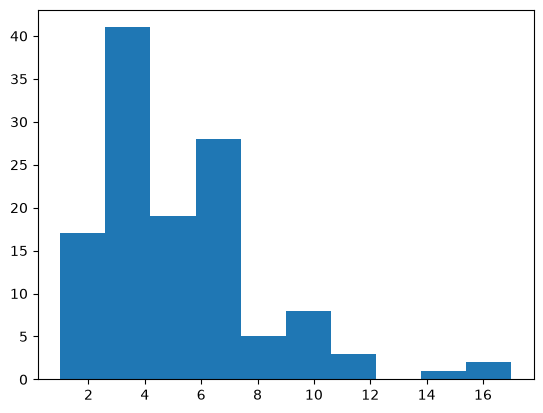

In [81]:
print(sum(cluster_sizes)/len(cluster_sizes))

plt.hist(cluster_sizes)
plt.show()

41


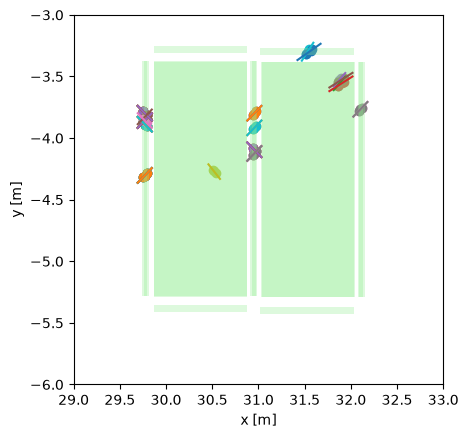

In [ ]:
# print(selected_points)

for cluster in clusters:
    X = np.array([hit_points[point_id] for point_id in cluster])
    plt.scatter(X[:,0], X[:,1])

    m, n, R = lineal_regression(X[:,0], X[:,1])

    a = min(X[:,0])
    b = max(X[:,0])

    e = 1.5*(b-a)
    a -= e
    b += e

    plt.plot([a,b], m*np.array([a,b]) + n)

ax = plt.gca()
plot_detector(ax)

print(len(clusters))

# plt.scatter(X[:,0], X[:,1])
plt.show()

# print(len(module_points))


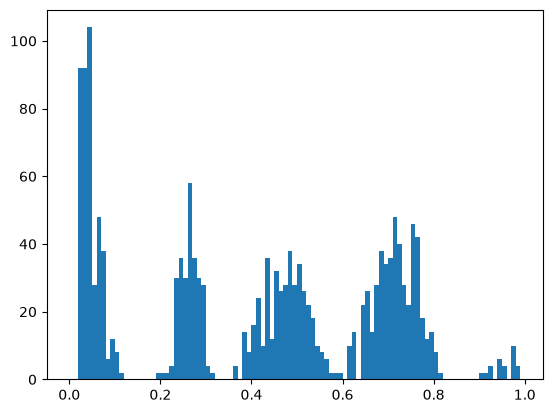

In [75]:
distances = []

for i, P in enumerate(hit_points):
    for j, Q in enumerate(hit_points):
        if i != j:
            PQ = Q - P
            d = np.sqrt(np.dot(PQ,PQ))
            distances.append(d)

fig, ax = plt.subplots()
ax.hist(distances, bins = np.arange(0, 1, 0.01))
plt.show()